# DAGGER Harmonics — Data Analysis

This notebook walks through the full pipeline from raw validation data to spherical harmonic transforms:

1. **Data structure** — understand what each record contains
2. **Single-timestep visualization** — station scatter maps of SuperMAG perturbations
3. **Grid interpolation + SHT** — scatter → regular grid → `RealSHT` (torch-harmonics)
4. **SH power spectrum** — energy distribution across degrees
5. **Time-series SHT fits** — loop over a window of consecutive records and track how coefficients evolve

---
### Dataset: `val_data_2010.p`

| Key | Shape | Description |
|---|---|---|
| `coords_radians` | `(2,)` tuple of `(175,)` arrays | Station positions: Magnetic Local Time (MLT) in radians, magnetic colatitude (rad) |
| `past_omni` | `(120,)` | Solar-wind/IMF inputs for the preceding 2 hours |
| `past_supermag` | `(1, 175, 6)` | SuperMAG readings at the most recent timestep |
| `future_supermag` | `(1, 175, 6)` | Target SuperMAG 30 min ahead |
| `past_dates` | `(120,)` | Unix epoch seconds for each past step |
| `future_dates` | `(1,)` | Unix epoch second for the prediction target |

SuperMAG columns (index 0–5): `maglat`, `mlt`, `dbe`, `dbn`, `ddbe_dt`, `ddbn_dt`


Each record is for 1 minute of SuperMAG data. 

## 1. Setup

In [33]:
import datetime
from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch_harmonics
from scipy.interpolate import griddata

from dagger_harmonics.data_utils import load_data, DEFAULT_DATA_PATH

In [34]:
# SuperMAG column index map
SUPERMAG_COLS = {"maglat": 0, "mlt": 1, "dbe": 2, "dbn": 3, "ddbe_dt": 4, "ddbn_dt": 5}


def supermag_col(supermag, col):
    """Extract a named column from a supermag array (T, N, 6) or (N, 6). Returns (N,)."""
    arr = np.asarray(supermag)
    if arr.ndim == 3:
        arr = arr[-1]  # most recent timestep
    return arr[:, SUPERMAG_COLS[col]]


def supermag_dbH(supermag):
    """Horizontal perturbation magnitude δbH = √(δbe² + δbn²). Always positive."""
    return np.sqrt(supermag_col(supermag, "dbe") ** 2 + supermag_col(supermag, "dbn") ** 2)


def style_polar_ax(ax):
    """Apply standard MLT polar axes styling: midnight at bottom, clockwise."""
    ax.set_theta_zero_location("S")
    ax.set_theta_direction(-1)
    mlt_ticks = np.arange(0, 24, 3)
    ax.set_xticks(mlt_ticks / 24 * 2 * np.pi)
    ax.set_xticklabels([f"{int(m):02d}" for m in mlt_ticks])
    ax.set_xlabel("MLT (hours)")

## 2. Load Data

In [35]:
data = load_data(DEFAULT_DATA_PATH)
print(f"Records: {len(data):,}")

t0 = datetime.datetime.fromtimestamp(data[0]["future_dates"].ravel()[0], tz=datetime.UTC)
t1 = datetime.datetime.fromtimestamp(data[-1]["future_dates"].ravel()[0], tz=datetime.UTC)
print(f"Time span: {t0:%Y-%m-%d %H:%M} → {t1:%Y-%m-%d %H:%M} UTC")

Records: 51,060
Time span: 2010-01-26 15:42 → 2010-12-06 10:47 UTC


## 3. Single-Timestep Visualization

Pull one record and display all four perturbation channels as polar scatter plots (MLT vs magnetic colatitude).

In [36]:
IDX = 0  # change to inspect a different record

record = data[IDX]
mlt_rad    = np.asarray(record["coords_radians"][0]).ravel()  # (175,)
mcolat_rad = np.asarray(record["coords_radians"][1]).ravel()  # (175,)

ts = datetime.datetime.fromtimestamp(record["future_dates"].ravel()[0], tz=datetime.UTC)
print(f"Record {IDX} — target time: {ts:%Y-%m-%d %H:%M} UTC | stations: {mlt_rad.size}")

Record 0 — target time: 2010-01-26 15:42 UTC | stations: 175


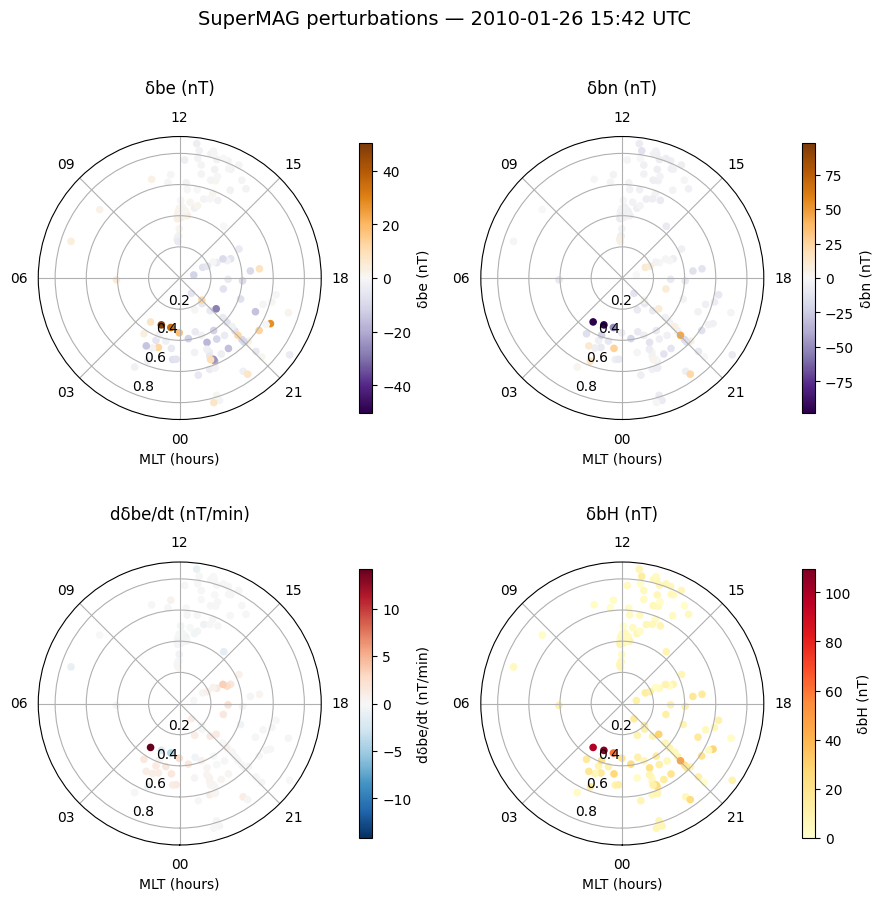

In [37]:
channels = [
    (supermag_col(record["past_supermag"], "dbe"),     "δbe (nT)",         "PuOr_r"),
    (supermag_col(record["past_supermag"], "dbn"),     "δbn (nT)",         "PuOr_r"),
    (supermag_col(record["past_supermag"], "ddbe_dt"), "dδbe/dt (nT/min)", "RdBu_r"),
    (supermag_dbH(record["past_supermag"]),             "δbH (nT)",         "YlOrRd"),
]

fig, axes = plt.subplots(2, 2, subplot_kw={"projection": "polar"}, figsize=(9, 9))

for ax, (values, label, cmap) in zip(axes.ravel(), channels):
    style_polar_ax(ax)
    absmax = np.nanmax(np.abs(values))
    vmin = 0 if cmap == "YlOrRd" else -absmax
    sc = ax.scatter(mlt_rad, mcolat_rad, c=values, cmap=cmap, vmin=vmin, vmax=absmax, s=20)
    fig.colorbar(sc, ax=ax, shrink=0.7, pad=0.1, label=label)
    ax.set_title(label, pad=12)

fig.suptitle(f"SuperMAG perturbations — {ts:%Y-%m-%d %H:%M} UTC", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 4. Grid Interpolation + Spherical Harmonic Transform

`torch-harmonics` `RealSHT` requires data on a **regular equiangular grid**.  
Since SuperMAG stations are scattered, we first interpolate with `scipy.interpolate.griddata`, then apply the transform.

**Grid convention**: colatitude 0 → π (north to south pole), longitude 0 → 2π.

In [38]:
# Grid resolution — must be even for RealSHT
NLAT, NLON = 64, 128

lat_grid = np.linspace(0, np.pi, NLAT)
lon_grid = np.linspace(0, 2 * np.pi, NLON, endpoint=False)
lon_mesh, lat_mesh = np.meshgrid(lon_grid, lat_grid)  # (NLAT, NLON)

sht  = torch_harmonics.RealSHT(NLAT, NLON, grid="equiangular")
isht = torch_harmonics.InverseRealSHT(NLAT, NLON, grid="equiangular")

print(f"Grid: {NLAT} × {NLON}  |  lmax = {sht.lmax}")

Grid: 64 × 128  |  lmax = 64


In [39]:
from scipy.interpolate import RegularGridInterpolator


def scatter_to_grid(mlt_rad, mcolat_rad, values, method="linear"):
    """Interpolate scattered station values onto the regular (NLAT, NLON) grid."""
    mask = np.isfinite(mlt_rad) & np.isfinite(mcolat_rad) & np.isfinite(values)
    points = np.column_stack([mlt_rad[mask], mcolat_rad[mask]])
    return griddata(points, values[mask], (lon_mesh, lat_mesh), method=method, fill_value=0.0)


def to_sht_coeffs(grid_np):
    """Apply RealSHT to a (NLAT, NLON) array. Returns complex (lmax, mmax+1) tensor."""
    t = torch.from_numpy(grid_np).float().unsqueeze(0).unsqueeze(0)
    return sht(t).squeeze()


def reconstruct_grid(grid_np):
    """Round-trip grid → SHT → iSHT. Returns (NLAT, NLON) array."""
    t = torch.from_numpy(grid_np).float().unsqueeze(0).unsqueeze(0)
    return isht(sht(t)).squeeze().numpy()


def power_spectrum(coeffs_2d):
    """Power per degree l: P_l = |C_l0|² + 2 Σ_{m>0} |C_lm|²"""
    power = []
    for l in range(coeffs_2d.shape[0]):
        p = coeffs_2d[l, 0].abs().pow(2)
        if coeffs_2d.shape[1] > 1:
            p = p + 2 * coeffs_2d[l, 1 : l + 1].abs().pow(2).sum()
        power.append(p.item())
    return np.array(power)


def reconstruction_mae(grid_np, mlt_rad, mcolat_rad, true_vals):
    """MAE between the SHT reconstruction (sampled at station locations) and true values.

    Measures how well the spherical harmonic fit captures the original scatter data.
    Lower = better fit.
    """
    recon = reconstruct_grid(grid_np)
    # grid axes: axis-0 = lat_grid (colatitude), axis-1 = lon_grid (MLT radians)
    interp = RegularGridInterpolator(
        (lat_grid, lon_grid), recon, method="linear", bounds_error=False, fill_value=np.nan
    )
    recon_at_stations = interp(np.column_stack([mcolat_rad, mlt_rad]))
    finite = np.isfinite(true_vals) & np.isfinite(recon_at_stations)
    if not finite.any():
        return np.nan
    return float(np.mean(np.abs(true_vals[finite] - recon_at_stations[finite])))

In [40]:
dbH_vals = supermag_dbH(record["past_supermag"])
dbe_vals = supermag_col(record["past_supermag"], "dbe")
dbn_vals = supermag_col(record["past_supermag"], "dbn")

grid_dbH = scatter_to_grid(mlt_rad, mcolat_rad, dbH_vals)
grid_dbe = scatter_to_grid(mlt_rad, mcolat_rad, dbe_vals)
grid_dbn = scatter_to_grid(mlt_rad, mcolat_rad, dbn_vals)

coeffs_dbH = to_sht_coeffs(grid_dbH)
coeffs_dbe = to_sht_coeffs(grid_dbe)
coeffs_dbn = to_sht_coeffs(grid_dbn)

recon_dbH = reconstruct_grid(grid_dbH)

print(f"Coefficient tensor shape: {tuple(coeffs_dbH.shape)}")
print(f"dbH grid  range: [{grid_dbH.min():.1f}, {grid_dbH.max():.1f}] nT")
print(f"dbH recon range: [{recon_dbH.min():.1f}, {recon_dbH.max():.1f}] nT")

Coefficient tensor shape: (64, 65)
dbH grid  range: [0.0, 96.7] nT
dbH recon range: [-7.4, 92.4] nT


### 4a. Station scatter → interpolated grid → SHT reconstruction

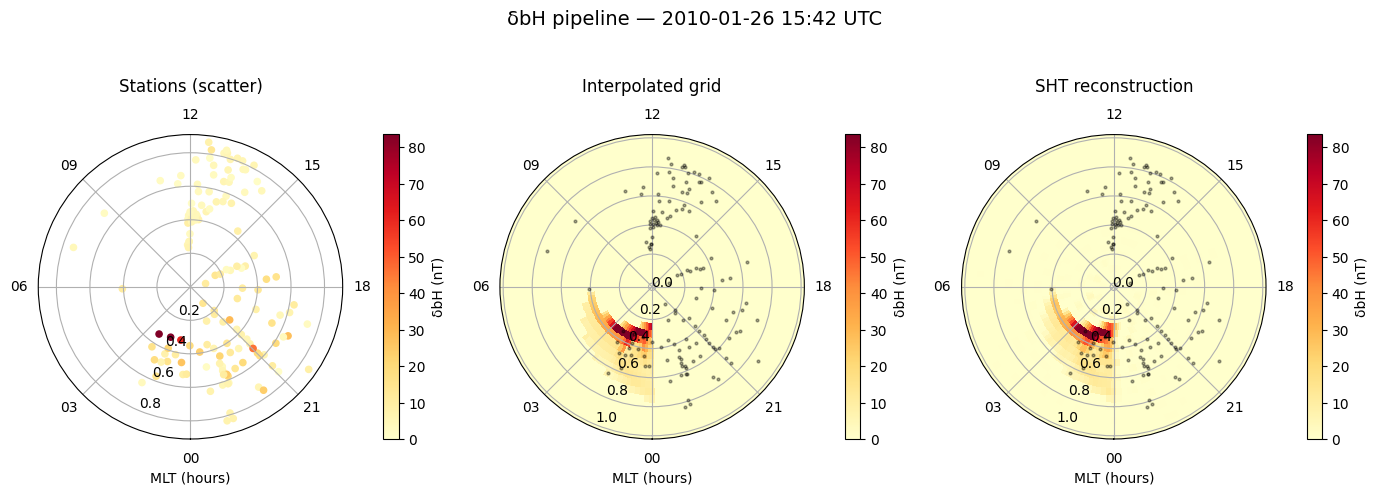

In [41]:
# Clip to polar cap for display
CAP_RAD = np.deg2rad(60)
cap = lat_grid <= CAP_RAD
theta_mesh_cap, r_mesh_cap = np.meshgrid(lon_grid, lat_grid[cap])

vmax_dbH = float(np.nanpercentile(dbH_vals[np.isfinite(dbH_vals)], 99))

fig, axes = plt.subplots(1, 3, subplot_kw={"projection": "polar"}, figsize=(14, 5))

titles = ["Stations (scatter)", "Interpolated grid", "SHT reconstruction"]
for ax, title in zip(axes, titles):
    style_polar_ax(ax)
    ax.set_title(title, pad=12)

# Panel 1 — raw scatter
sc = axes[0].scatter(mlt_rad, mcolat_rad, c=dbH_vals, cmap="YlOrRd",
                     vmin=0, vmax=vmax_dbH, s=20)
fig.colorbar(sc, ax=axes[0], shrink=0.7, pad=0.1, label="δbH (nT)")

# Panels 2 & 3 — grid heatmaps (r_mesh_cap in radians, matching the scatter's radial axis)
for ax, grid_data in zip(axes[1:], [grid_dbH, recon_dbH]):
    im = ax.pcolormesh(theta_mesh_cap, r_mesh_cap, grid_data[cap, :],
                       cmap="YlOrRd", vmin=0, vmax=vmax_dbH, shading="auto")
    ax.scatter(mlt_rad, mcolat_rad, s=4, c="k", alpha=0.35, zorder=5)
    fig.colorbar(im, ax=ax, shrink=0.7, pad=0.1, label="δbH (nT)")

fig.suptitle(f"δbH pipeline — {ts:%Y-%m-%d %H:%M} UTC", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 4b. SH Power Spectrum (single timestep)

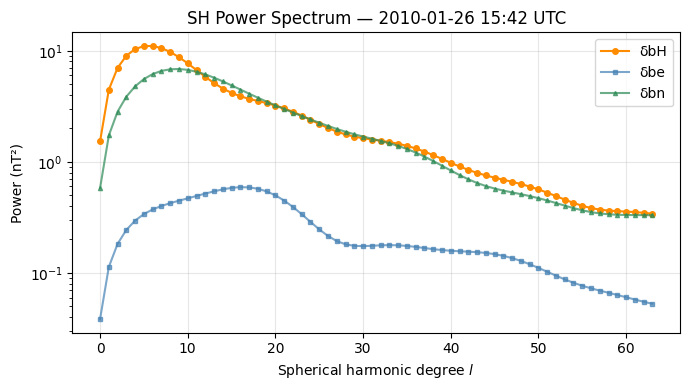

In [42]:
ps_dbH = power_spectrum(coeffs_dbH)
ps_dbe = power_spectrum(coeffs_dbe)
ps_dbn = power_spectrum(coeffs_dbn)
degrees = np.arange(len(ps_dbH))

fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogy(degrees, ps_dbH, marker="o", ms=4, color="darkorange", label="δbH")
ax.semilogy(degrees, ps_dbe, marker="s", ms=3, color="steelblue", alpha=0.7, label="δbe")
ax.semilogy(degrees, ps_dbn, marker="^", ms=3, color="seagreen", alpha=0.7, label="δbn")
ax.set_xlabel("Spherical harmonic degree $l$")
ax.set_ylabel("Power (nT²)")
ax.set_title(f"SH Power Spectrum — {ts:%Y-%m-%d %H:%M} UTC")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Time-Series of SHT Fits

All 51 000+ records are sorted by their target timestamp. For each record we:

1. Extract `past_supermag` δbH at the station locations
2. Interpolate to the regular grid and compute the SHT
3. Track the power spectrum over time
4. Compute the **reconstruction MAE** — the mean absolute error between the SHT reconstruction sampled back at station locations and the original measurements. This is a quality metric for the fit: lower = the spherical harmonic expansion captures the spatial pattern well.

In [43]:
# Sort all records by target timestamp
all_sorted = sorted(range(len(data)), key=lambda i: data[i]["future_dates"].ravel()[0])

N_STEPS = min(500, len(all_sorted))
window = all_sorted[:N_STEPS]

t_first = datetime.datetime.fromtimestamp(data[window[0]]["future_dates"].ravel()[0], tz=datetime.UTC)
t_last  = datetime.datetime.fromtimestamp(data[window[-1]]["future_dates"].ravel()[0], tz=datetime.UTC)
print(f"{N_STEPS} records: {t_first:%Y-%m-%d %H:%M} → {t_last:%Y-%m-%d %H:%M} UTC")

500 records: 2010-01-26 15:42 → 2010-01-27 00:01 UTC


In [44]:
timestamps  = []
ps_series   = []
total_power = []
low_power   = []   # l ≤ 4  (large-scale structure)
high_power  = []   # l > 4  (small-scale structure)
mae_series  = []   # SHT reconstruction MAE at station locations

for idx in window:
    rec = data[idx]
    t = datetime.datetime.fromtimestamp(rec["future_dates"].ravel()[0], tz=datetime.UTC)
    timestamps.append(t)

    mlt_i   = np.asarray(rec["coords_radians"][0]).ravel()
    mcol_i  = np.asarray(rec["coords_radians"][1]).ravel()
    vals    = supermag_dbH(rec["past_supermag"])

    grid    = scatter_to_grid(mlt_i, mcol_i, vals)
    coeffs  = to_sht_coeffs(grid)
    ps      = power_spectrum(coeffs)
    ps_series.append(ps)

    total_power.append(float(ps.sum()))
    low_power.append(float(ps[:5].sum()))
    high_power.append(float(ps[5:].sum()))
    mae_series.append(reconstruction_mae(grid, mlt_i, mcol_i, vals))

ps_array = np.array(ps_series)  # (N_STEPS, lmax)
mae_array = np.array(mae_series)
print(f"Computed SHT for {N_STEPS} records — ps_array shape: {ps_array.shape}")
print(f"Reconstruction MAE — mean: {np.nanmean(mae_array):.2f} nT  |  max: {np.nanmax(mae_array):.2f} nT")

Computed SHT for 500 records — ps_array shape: (500, 64)
Reconstruction MAE — mean: 2.58 nT  |  max: 9.97 nT


### 5a. SHT Reconstruction MAE Over Time

How well does the spherical harmonic expansion reproduce the original station measurements at each timestep?  
Spikes indicate either a complex spatial pattern that needs higher degree terms, or timesteps with unusually large perturbations.

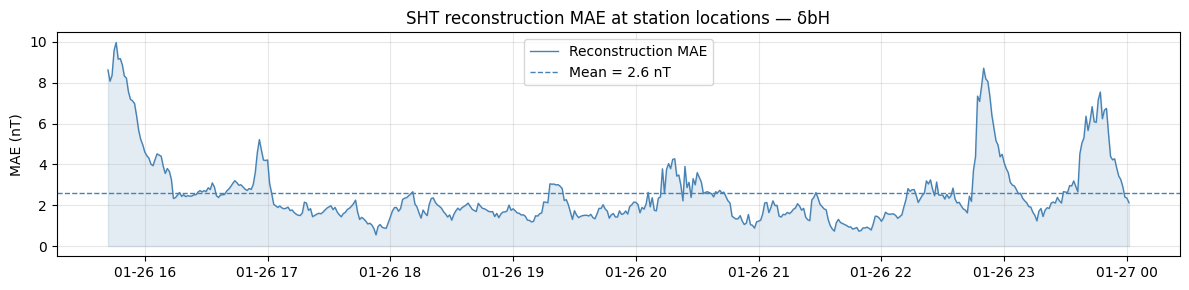

In [45]:
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(timestamps, mae_array, color="steelblue", linewidth=1.0, label="Reconstruction MAE")
ax.fill_between(timestamps, 0, mae_array, alpha=0.15, color="steelblue")
ax.axhline(np.nanmean(mae_array), color="steelblue", linewidth=1.0, linestyle="--",
           label=f"Mean = {np.nanmean(mae_array):.1f} nT")
ax.set_ylabel("MAE (nT)")
ax.set_title("SHT reconstruction MAE at station locations — δbH")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 5a. Total SH Power Over Time

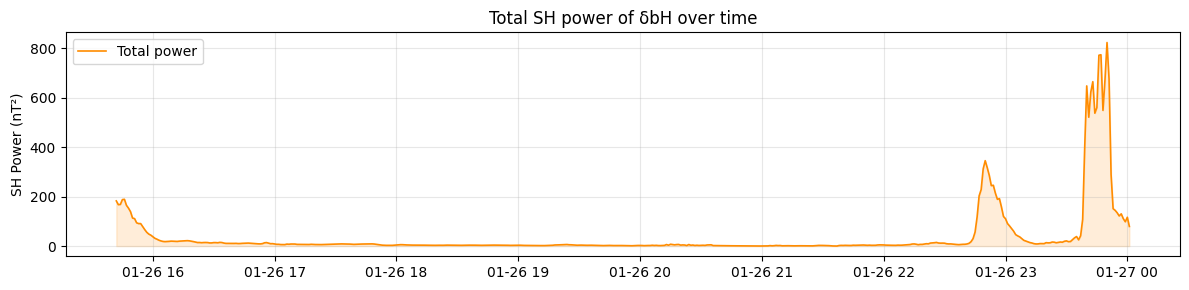

In [46]:
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(timestamps, total_power, color="darkorange", linewidth=1.2, label="Total power")
ax.fill_between(timestamps, 0, total_power, alpha=0.15, color="darkorange")
ax.set_ylabel("SH Power (nT²)")
ax.set_title("Total SH power of δbH over time")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 5b. Large-scale vs Small-scale Power

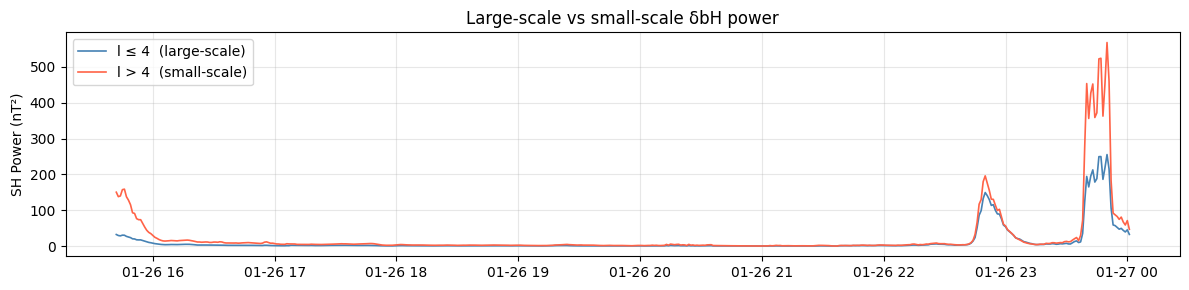

In [47]:
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(timestamps, low_power,  color="steelblue", linewidth=1.2, label="l ≤ 4  (large-scale)")
ax.plot(timestamps, high_power, color="tomato",    linewidth=1.2, label="l > 4  (small-scale)")
ax.set_ylabel("SH Power (nT²)")
ax.set_title("Large-scale vs small-scale δbH power")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 5c. Power Spectrum Heatmap Over Time

Each column is one timestep's power spectrum. Log-scaled to reveal low-power structure.

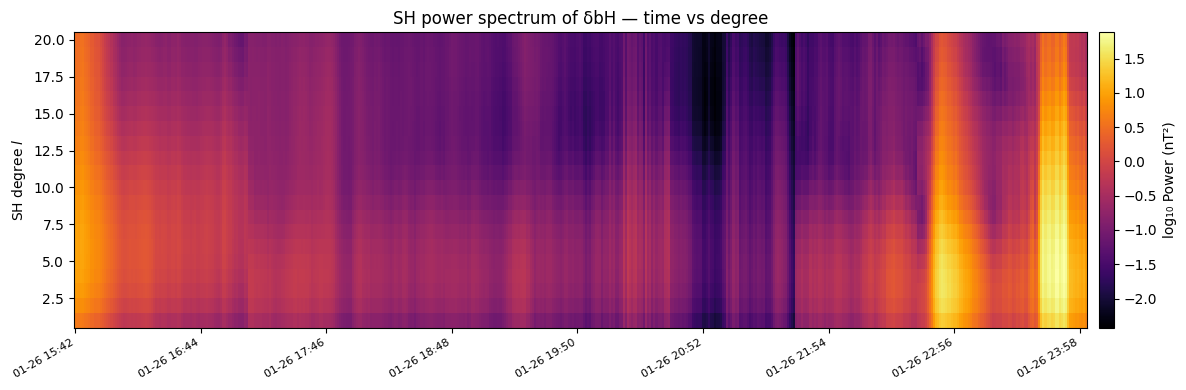

In [48]:
L_MAX_PLOT = min(21, ps_array.shape[1])
ps_plot = ps_array[:, 1:L_MAX_PLOT].T  # (degrees, time) — skip l=0 DC offset

fig, ax = plt.subplots(figsize=(13, 4))
im = ax.pcolormesh(
    range(len(timestamps)),
    range(1, L_MAX_PLOT),
    np.log10(ps_plot + 1e-6),
    cmap="inferno",
    shading="auto",
)
plt.colorbar(im, ax=ax, pad=0.01, label="log₁₀ Power (nT²)")

tick_step = max(1, len(timestamps) // 8)
tick_pos  = list(range(0, len(timestamps), tick_step))
ax.set_xticks(tick_pos)
ax.set_xticklabels([timestamps[i].strftime("%m-%d %H:%M") for i in tick_pos],
                   rotation=30, ha="right", fontsize=8)
ax.set_ylabel("SH degree $l$")
ax.set_title("SH power spectrum of δbH — time vs degree")
plt.tight_layout()
plt.show()

### 5d. Per-degree Power Time Series

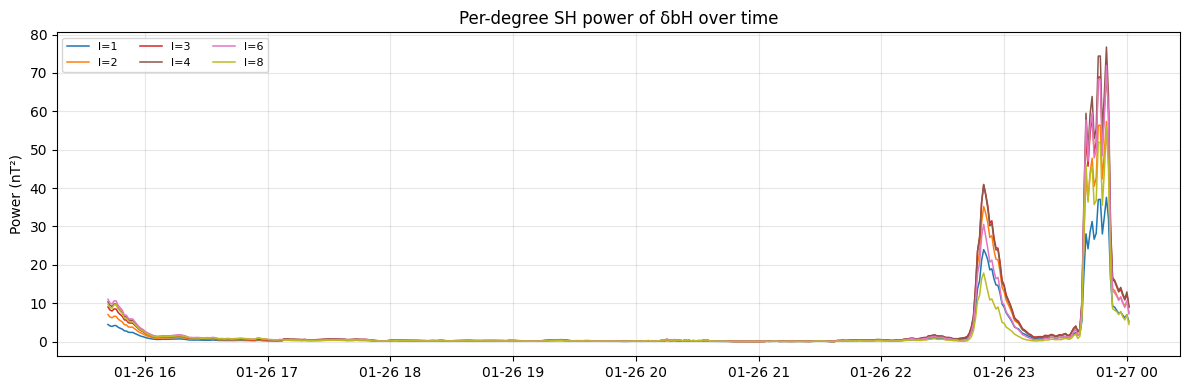

In [49]:
DEGREES_TO_PLOT = [1, 2, 3, 4, 6, 8]

fig, ax = plt.subplots(figsize=(12, 4))
for i, l in enumerate(DEGREES_TO_PLOT):
    if l < ps_array.shape[1]:
        ax.plot(timestamps, ps_array[:, l], linewidth=1.1,
                color=plt.cm.tab10(i / len(DEGREES_TO_PLOT)), label=f"l={l}")

ax.set_ylabel("Power (nT²)")
ax.set_title("Per-degree SH power of δbH over time")
ax.legend(ncol=3, fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 5e. Snapshot Comparison — Quiet vs Active

Compare the polar map at the quietest and most active timestep in the window.

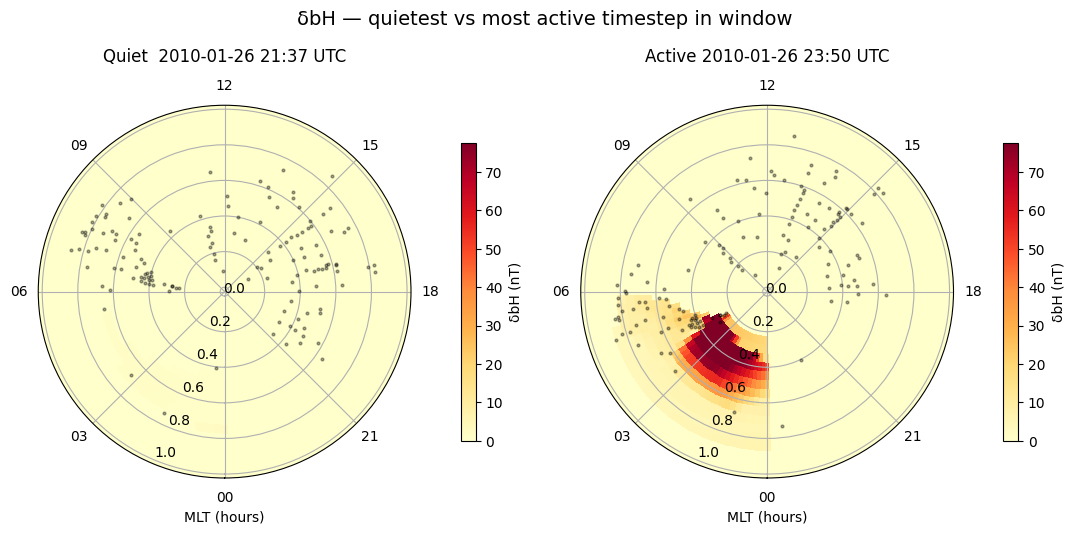

In [50]:
idx_quiet  = int(np.argmin(total_power))
idx_active = int(np.argmax(total_power))


def get_dbH_grid(window_idx):
    rec     = data[window[window_idx]]
    mlt_r   = np.asarray(rec["coords_radians"][0]).ravel()
    mcol_r  = np.asarray(rec["coords_radians"][1]).ravel()
    vals    = supermag_dbH(rec["past_supermag"])
    return scatter_to_grid(mlt_r, mcol_r, vals), vals, mlt_r, mcol_r


grid_quiet,  vals_quiet,  mlt_quiet,  mcol_quiet  = get_dbH_grid(idx_quiet)
grid_active, vals_active, mlt_active, mcol_active = get_dbH_grid(idx_active)

all_finite = np.concatenate([
    vals_active[np.isfinite(vals_active)],
    vals_quiet[np.isfinite(vals_quiet)],
])
vmax_shared = float(np.nanpercentile(all_finite, 99))

fig, axes = plt.subplots(1, 2, subplot_kw={"projection": "polar"}, figsize=(11, 5))

snap_labels = [
    f"Quiet  {timestamps[idx_quiet]:%Y-%m-%d %H:%M} UTC",
    f"Active {timestamps[idx_active]:%Y-%m-%d %H:%M} UTC",
]
for ax, grid_data, mlt_r, mcol_r, title in zip(
    axes, [grid_quiet, grid_active], [mlt_quiet, mlt_active], [mcol_quiet, mcol_active], snap_labels
):
    style_polar_ax(ax)
    ax.set_title(title, pad=12)
    im = ax.pcolormesh(theta_mesh_cap, r_mesh_cap, grid_data[cap, :],
                       cmap="YlOrRd", vmin=0, vmax=vmax_shared, shading="auto")
    ax.scatter(mlt_r, mcol_r, s=4, c="k", alpha=0.35, zorder=5)
    fig.colorbar(im, ax=ax, shrink=0.7, pad=0.1, label="δbH (nT)")

fig.suptitle("δbH — quietest vs most active timestep in window", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## OMNI Graphing

In [51]:
import pandas as pd
df = pd.DataFrame(data)

record_data = df.iloc[0, :]

past_omni = record_data.get('past_omni')
print(past_omni.shape)
past_dates = record_data.get('past_dates')
print(past_dates.shape)

df = pd.DataFrame(data)

record_data = df.iloc[0, :]

past_omni = record_data.get('past_omni')
print(past_omni.shape)
past_dates = record_data.get('past_dates')
print(past_dates.shape)

# OMNI / derived features:
# Using 1-min cadence OMNI (IMF & solar wind). Base measurements include:
#   Bx, By, Bz (GSM IMF components), BT (IMF total), VSW (solar wind speed),
#   T (proton temperature), theta_c (IMF clock angle), F10.7 (10.7 cm radio flux)
# Following Weimer (2013) we generate "good" features to accelerate model training:
# Inputs to the model (in order): 
#   Bx, By, Bz, BT, VSW, t (dipole axis angle, rad), theta_c, T, sqrt(F10.7),
#   BT*cos(theta_c), VSW*cos(theta_c), t*cos(theta_c), sqrt(F10.7)*cos(theta_c),
#   BT*sin(theta_c), VSW*sin(theta_c), t*sin(theta_c), sqrt(F10.7)*sin(theta_c),
#   BT*cos(2*theta_c), VSW*cos(2*theta_c), BT*sin(2*theta_c), VSW*sin(2*theta_c)
print(past_omni[0])
print(past_dates[0])

(120, 15)
(120,)
(120, 15)
(120,)
[-1.71000000e+00  2.59000000e+00  2.40000000e+00             nan
             nan             nan             nan             nan
             nan             nan             nan             nan
  8.23455931e-01  1.88646973e-13 -2.98299452e-01]
1264511520.0


In [52]:
# ---- OMNI feature metadata (15 features, 1-min cadence, 120-step / 2-hour window) ----
FEATURE_NAMES = [
    "Bx (nT)", "By (nT)", "Bz (nT)", "BT (nT)", "VSW (km/s)",
    "t (rad)", "θc (rad)", "T (K)", "√F10.7",
    "BT·cos(θc)", "VSW·cos(θc)", "t·cos(θc)", "√F10.7·cos(θc)",
    "BT·sin(θc)", "VSW·sin(θc)",
]

FEATURE_GROUPS = [
    ("IMF Components",     [0, 1, 2, 3]),
    ("Solar Wind & Index", [4, 7, 8]),
    ("Orientation",        [5, 6]),
    ("Derived — cos(θc)",  [9, 10, 11, 12]),
    ("Derived — sin(θc)",  [13, 14]),
]
GROUP_COLORS = ["steelblue", "darkorange", "seagreen", "mediumpurple", "tomato"]

record   = data[IDX]
omni     = np.asarray(record["past_omni"])   # (120, 15)
pdates   = np.asarray(record["past_dates"])  # (120,) Unix s
times    = [datetime.datetime.fromtimestamp(d, tz=datetime.UTC) for d in pdates]
target_t = datetime.datetime.fromtimestamp(record["future_dates"].ravel()[0], tz=datetime.UTC)

print(f"OMNI shape : {omni.shape}")
print(f"Window     : {times[0]:%Y-%m-%d %H:%M} → {times[-1]:%H:%M} UTC  (1-min cadence)")
print(f"Target     : {target_t:%Y-%m-%d %H:%M} UTC")
print()
print(f"{'Feature':<32s}  NaN%    min        max")
print("-" * 62)
for name, col in zip(FEATURE_NAMES, omni.T):
    frac = np.isnan(col).mean()
    lo   = np.nanmin(col) if not np.all(np.isnan(col)) else float("nan")
    hi   = np.nanmax(col) if not np.all(np.isnan(col)) else float("nan")
    print(f"  {name:<30s}  {frac:4.0%}  {lo:9.3f}  {hi:9.3f}")

OMNI shape : (120, 15)
Window     : 2010-01-26 13:12 → 15:11 UTC  (1-min cadence)
Target     : 2010-01-26 15:42 UTC

Feature                           NaN%    min        max
--------------------------------------------------------------
  Bx (nT)                          13%     -3.820      0.450
  By (nT)                          13%     -0.300      3.470
  Bz (nT)                          13%     -3.430      3.710
  BT (nT)                          36%   -381.800   -351.300
  VSW (km/s)                       36%    -14.200     18.400
  t (rad)                          36%    -24.300     16.200
  θc (rad)                         36%      4.240      5.990
  T (K)                            36%      1.110      1.610
  √F10.7                           36%  53453.000  121643.000
  BT·cos(θc)                       36%    203.890    203.980
  VSW·cos(θc)                      36%     -6.950     -6.870
  t·cos(θc)                        36%     -6.950     -6.870
  √F10.7·cos(θc)              

### 6a. Grouped OMNI Feature Time Series

All 15 OMNI features plotted over the 2-hour input window, color-coded by group. Gaps in lines indicate NaN (OMNI data gaps). Line styles within each group distinguish individual features.

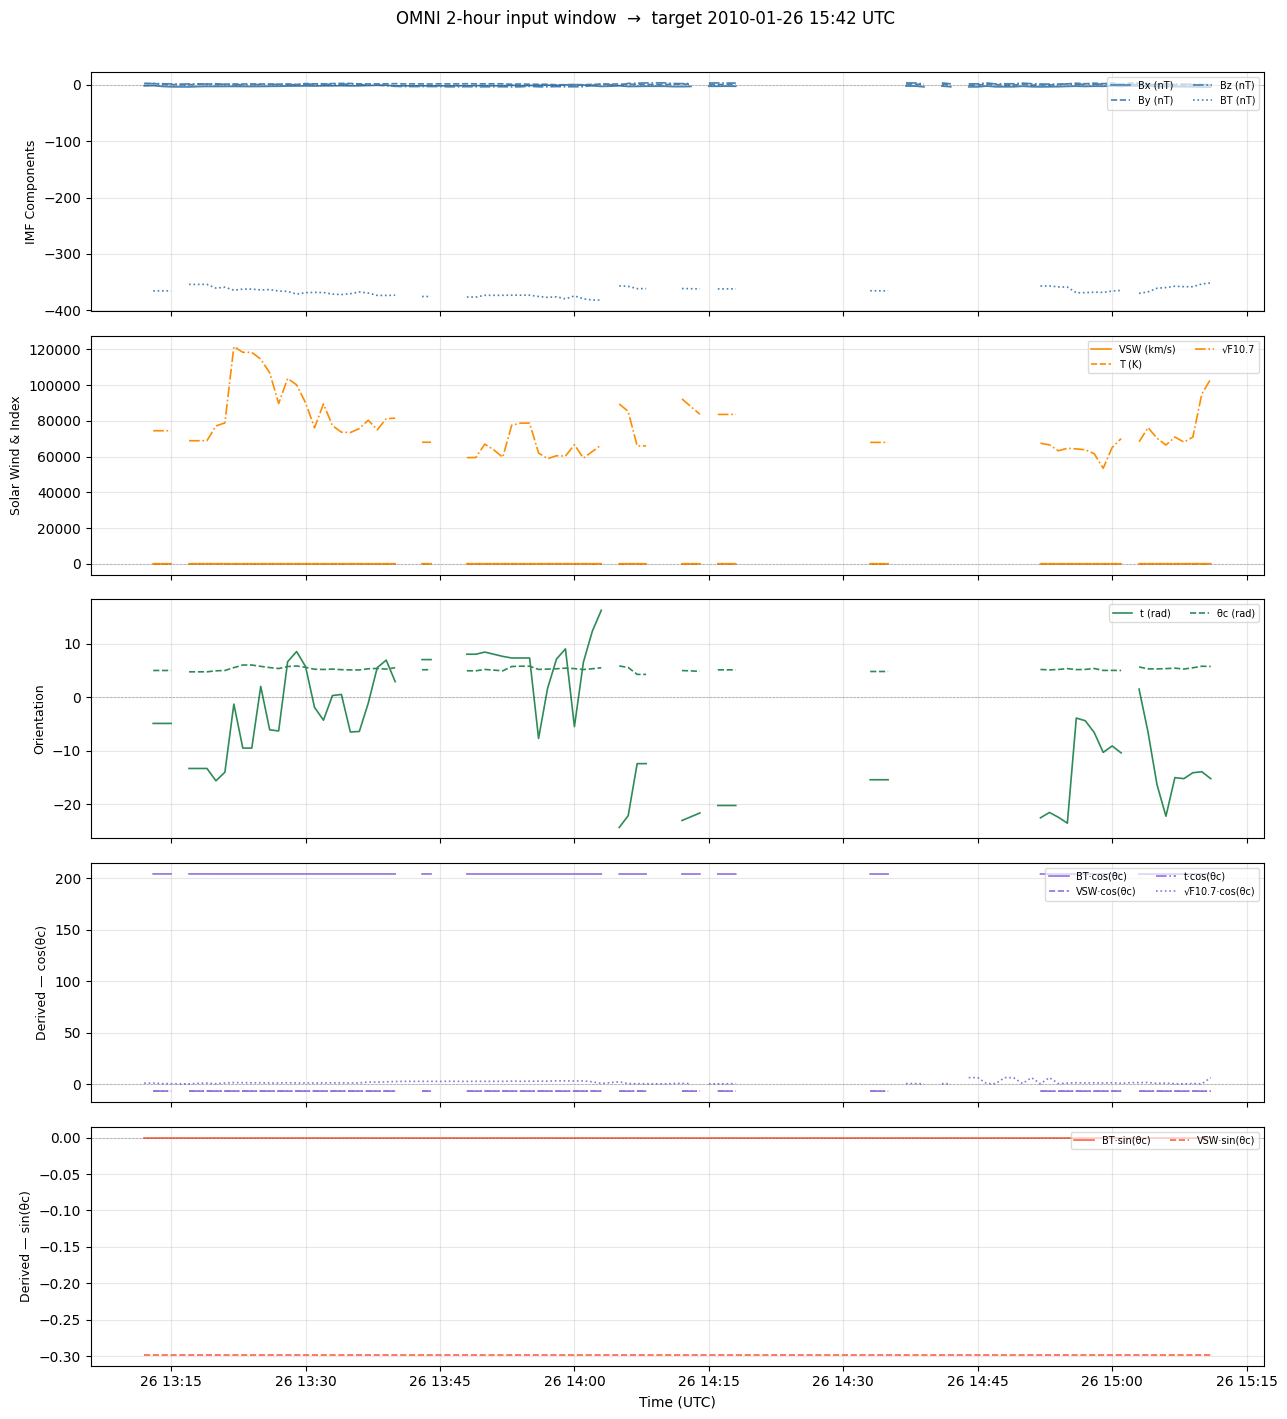

In [53]:
LINESTYLES = ["-", "--", "-.", ":", (0, (3, 1, 1, 1))]

fig, axes = plt.subplots(len(FEATURE_GROUPS), 1,
                         figsize=(13, 2.8 * len(FEATURE_GROUPS)), sharex=True)

for ax, (grp_name, feat_idxs), gcol in zip(axes, FEATURE_GROUPS, GROUP_COLORS):
    for j, fi in enumerate(feat_idxs):
        ax.plot(times, omni[:, fi],
                linewidth=1.2, linestyle=LINESTYLES[j % len(LINESTYLES)],
                color=gcol, label=FEATURE_NAMES[fi])
    ax.axhline(0, color="k", linewidth=0.5, linestyle="--", alpha=0.3)
    ax.set_ylabel(grp_name, fontsize=9)
    ax.legend(loc="upper right", fontsize=7, ncol=2, framealpha=0.7)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Time (UTC)")
fig.suptitle(
    f"OMNI 2-hour input window  →  target {target_t:%Y-%m-%d %H:%M} UTC",
    fontsize=12, y=1.01,
)
plt.tight_layout()
plt.show()

### 6b. OMNI Feature Matrix (Heatmap)

Each row is one feature, each column one minute of the 2-hour window, normalized to [−1, 1] per row so all features share the same color scale. **Gray cells are NaN** (missing OMNI data).

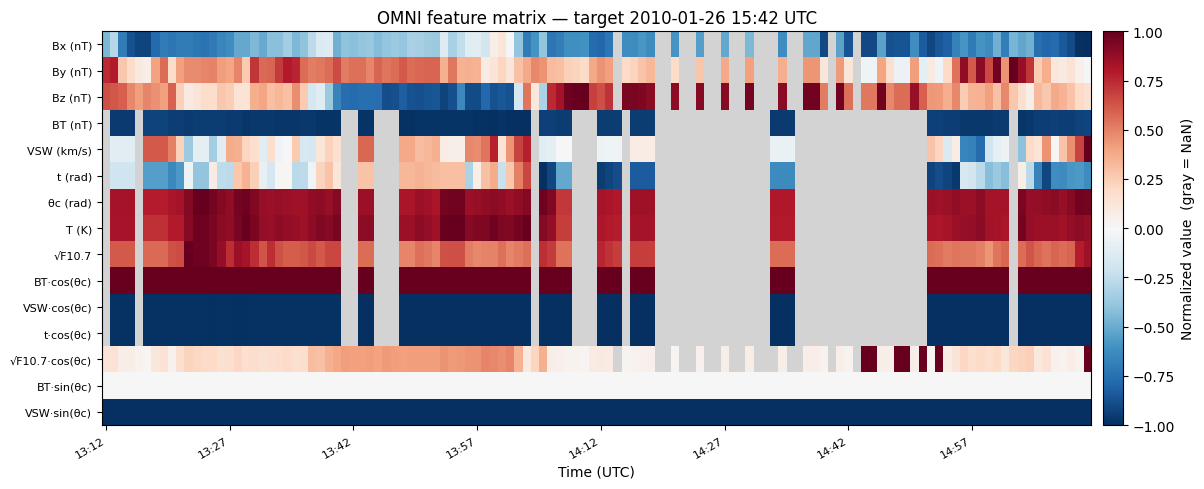

In [54]:
omni_norm = omni.copy().astype(float)
for fi in range(omni_norm.shape[1]):
    col = omni_norm[:, fi]
    absmax = np.nanmax(np.abs(col)) if not np.all(np.isnan(col)) else 1.0
    omni_norm[:, fi] = col / max(absmax, 1e-9)

cmap_nan = plt.get_cmap("RdBu_r").copy()
cmap_nan.set_bad("lightgray")

tick_pos = list(range(0, len(times), 15))

fig, ax = plt.subplots(figsize=(13, 5))
im = ax.imshow(np.ma.masked_invalid(omni_norm.T), aspect="auto",
               cmap=cmap_nan, vmin=-1, vmax=1,
               interpolation="nearest", origin="upper")
ax.set_yticks(range(len(FEATURE_NAMES)))
ax.set_yticklabels(FEATURE_NAMES, fontsize=8)
ax.set_xticks(tick_pos)
ax.set_xticklabels([times[i].strftime("%H:%M") for i in tick_pos],
                   rotation=30, ha="right", fontsize=8)
ax.set_xlabel("Time (UTC)")
plt.colorbar(im, ax=ax, pad=0.01, label="Normalized value  (gray = NaN)")
ax.set_title(f"OMNI feature matrix — target {target_t:%Y-%m-%d %H:%M} UTC")
plt.tight_layout()
plt.show()

### 6c. Data Completeness Across Records

What fraction of 1-minute OMNI values are missing across a representative sample of the dataset?  
Bx/By/Bz are typically best-observed; T, BT, and derived quantities inherit their missingness from the base OMNI measurements.

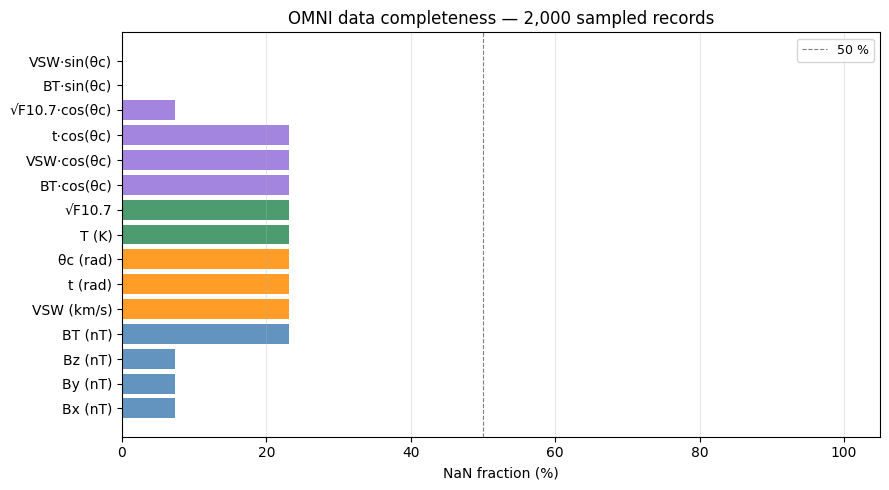


Feature                           Valid%
  Bx (nT)                           92.7%
  By (nT)                           92.7%
  Bz (nT)                           92.7%
  BT (nT)                           76.9%
  VSW (km/s)                        76.9%
  t (rad)                           76.9%
  θc (rad)                          76.9%
  T (K)                             76.9%
  √F10.7                            76.8%
  BT·cos(θc)                        76.9%
  VSW·cos(θc)                       76.9%
  t·cos(θc)                         76.9%
  √F10.7·cos(θc)                    92.7%
  BT·sin(θc)                        100.0%
  VSW·sin(θc)                       100.0%


In [55]:
N_SAMPLE = min(2000, len(data))
sample_idxs = np.linspace(0, len(data) - 1, N_SAMPLE, dtype=int)

nan_counts   = np.zeros(len(FEATURE_NAMES))
total_counts = np.zeros(len(FEATURE_NAMES))
for si in sample_idxs:
    o = np.asarray(data[si]["past_omni"])
    nan_counts   += np.isnan(o).sum(axis=0)
    total_counts += o.shape[0]
nan_frac_all = nan_counts / total_counts

bar_colors = [
    GROUP_COLORS[gi]
    for gi, (_, idxs) in enumerate(FEATURE_GROUPS)
    for _ in idxs
]

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(FEATURE_NAMES, nan_frac_all * 100, color=bar_colors, alpha=0.85)
ax.axvline(50, color="k", linestyle="--", linewidth=0.8, alpha=0.5, label="50 %")
ax.set_xlabel("NaN fraction (%)")
ax.set_title(f"OMNI data completeness — {N_SAMPLE:,} sampled records")
ax.set_xlim(0, 105)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

print(f"\n{'Feature':<32s}  Valid%")
for name, frac in zip(FEATURE_NAMES, nan_frac_all):
    print(f"  {name:<32s}  {(1 - frac):.1%}")

### 6d. Solar-Wind Driving and SuperMAG Response

For each record in the 500-step window, the 2-hour mean of key OMNI features is compared to the mean δbH at the target time, revealing driving relationships.

* **Bz** — southward IMF drives dayside reconnection and storm-time ring current injection
* **BT** — total IMF magnitude (coupling efficiency proxy)
* **VSW** — solar wind speed (dynamic pressure)
* **θc** — IMF clock angle (0 = northward, π = southward)

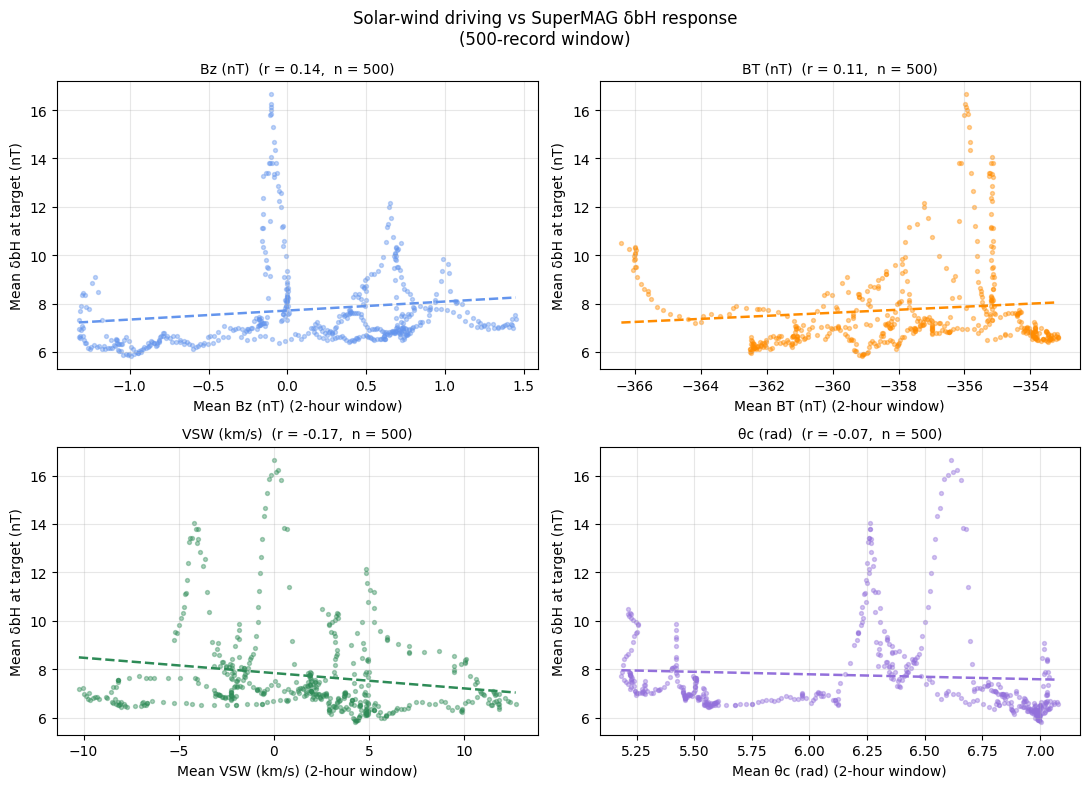

: 

In [ ]:
DRIVER_COLS   = {"Bz (nT)": 2, "BT (nT)": 3, "VSW (km/s)": 4, "θc (rad)": 6}
DRIVER_COLORS = {
    "Bz (nT)": "cornflowerblue", "BT (nT)": "darkorange",
    "VSW (km/s)": "seagreen", "θc (rad)": "mediumpurple",
}

drivers  = {k: [] for k in DRIVER_COLS}
resp_dbH = []

for wi in window:
    rec = data[wi]
    o   = np.asarray(rec["past_omni"])
    for name, fi in DRIVER_COLS.items():
        drivers[name].append(np.nanmean(o[:, fi]))
    resp_dbH.append(float(np.nanmean(supermag_dbH(rec["past_supermag"]))))

resp_arr = np.array(resp_dbH)

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, (feat_name, fi) in zip(axes.ravel(), DRIVER_COLS.items()):
    x     = np.array(drivers[feat_name])
    color = DRIVER_COLORS[feat_name]
    valid = np.isfinite(x) & np.isfinite(resp_arr)
    ax.scatter(x[valid], resp_arr[valid], s=8, alpha=0.4, color=color)
    if valid.sum() > 10:
        m, b = np.polyfit(x[valid], resp_arr[valid], 1)
        xr   = np.array([np.nanmin(x[valid]), np.nanmax(x[valid])])
        ax.plot(xr, m * xr + b, color=color, linewidth=1.8, linestyle="--")
        r = np.corrcoef(x[valid], resp_arr[valid])[0, 1]
        ax.set_title(f"{feat_name}  (r = {r:.2f},  n = {valid.sum()})", fontsize=10)
    else:
        ax.set_title(f"{feat_name}  (n = {valid.sum()} — insufficient data)")
    ax.set_xlabel(f"Mean {feat_name} (2-hour window)")
    ax.set_ylabel("Mean δbH at target (nT)")
    ax.grid(True, alpha=0.3)

fig.suptitle("Solar-wind driving vs SuperMAG δbH response\n(500-record window)", fontsize=12)
plt.tight_layout()
plt.show()